### Use saved finetuned model for prediction

In [1]:
# Import modules

import torch
import torch.nn as nn
from torchvision import models, transforms

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
def predict_model(model, image, labels):

    # Read in the image
    img = Image.open(image).convert("RGB")
    
    # Apply same transforms as used for resnet18 model
    transform = transforms.Compose([
        transforms.CenterCrop(224),
        transforms.Resize(256),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    image = transform(img)
    image = image.unsqueeze(0)  # Add batch dimension
    
    model.eval()

    with torch.no_grad():
        inputs = image.to(device)

        outputs = model(inputs)
        # _, preds = torch.max(outputs, 1)   # When using the model for inferencing, we can use "torch.max" (this give max value & index) OR
        preds = torch.argmax(outputs, 1)     # we can use "torch.argmax" - this give the index with the highest output
        
        # Plot image and predictions
        plt.imshow(img)
        plt.title('Prediction: ' + labels[preds])
        plt.show()
        
        return preds        

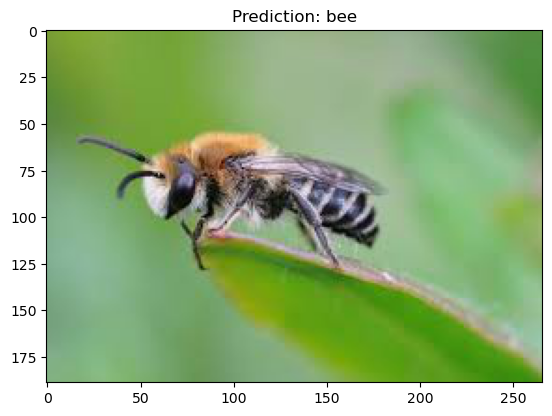

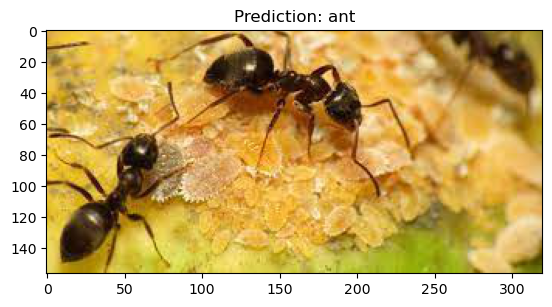

In [3]:
# Choose to use GPU or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create a list of the classes so we can use it to printout later
targets = ['ant','bee']

# load best model weights
model = models.resnet18()
num_ftrs = model.fc.in_features  # resnet18 final fully connected layer (fc)
model.fc = nn.Linear(num_ftrs, 2)   # We need to modify the final output of the model to 2

# Load the save model weights to the model
model.load_state_dict(torch.load('best_model_params.pt'))
model = model.to(device)

# Predict using the model
for i in ['bee.jpg','ant.jpg']:
    predict_model(model,i,targets)